Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import struct
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import  LinearRegression
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn import ensemble
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score
from sklearn.linear_model import ElasticNet
#R2 ยิ่งน้อยหมายถึงตัวแบบมีความผิดพลาดเพิ่มขึ้น ดังนั้น ค่า R2 ที่ต่ำ เป็นการเตือนให้รู้ว่าการทำนายนั้นมีความแม่ยำน้อย 
#เมื่อ R2 ยิ่งมีค่าเข้าใกล้ 1 มากเท่าไหร่ แสดงว่าความสัมพันธ์ระหว่างค่าความเข้มข้นของสารที่วิเคราะห์และค่าที่ได้จากการวิเคราะห์ว่าเป็นเส้นตรงมากขึ้นเท่านั้น


Preprocessing data

In [ ]:
import pandas as pd
import struct

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Sn_Project/thermo_injection.txt', sep=" ", header=None)

mylist = []
for i in range(1,len(data) - 1,4):
  DEX_X = data[3][i].replace(',','').split("[")
  DEX_Y = data[4][i].split("]")
  HEX_X = hex(int(DEX_X[1]))
  HEX_X = str(HEX_X).replace('0x','').upper()
  if len(HEX_X) < 4:
    HEX_X = '0'+ HEX_X
  HEX_Y = hex(int(DEX_Y[0]))
  HEX_Y = str(HEX_Y).replace('0x','').upper()
  if len(HEX_Y) < 4:
    HEX_Y = '0'+ HEX_Y
  Temp = HEX_Y + HEX_X
  Temp = struct.unpack('!f', bytes.fromhex(Temp))[0]
  TempC = (Temp - 273.15)
  TempC_2_decimal = "{:.2f}".format(TempC)
  Float_temp = float( TempC_2_decimal) #!!!!

  mylist.append(Float_temp)

In [ ]:
mylist

In [ ]:
df = pd.DataFrame(mylist,columns = ['temp'])
df.insert(0, "time_sec", [i for i in range(0,len(mylist)*5,5)], True) 
df.insert(1, "time_min", df.time_sec/60, True) 

**Descriptive data**

In [ ]:
df.head(10)

,time_sec,time_min,temp
0,0,0.000000,44.9
1,5,0.083333,45.0
2,10,0.166667,45.1
3,15,0.250000,45.3
4,20,0.333333,44.7
5,25,0.416667,45.0
6,30,0.500000,45.1
7,35,0.583333,45.2
8,40,0.666667,45.1
9,45,0.750000,45.1


In [ ]:
df.shape

(231, 3)

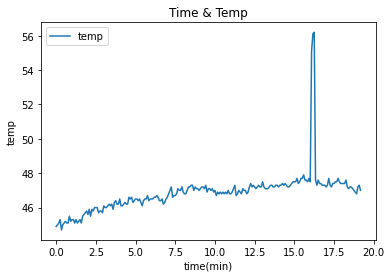

In [ ]:
import matplotlib.pyplot as plt
df.plot(x='time_min', y='temp')
plt.title('Time & Temp')
plt.xlabel('time(min)')
plt.ylabel('temp')
plt.show()

Check distribution

Text(0, 0.5, 'Temp')

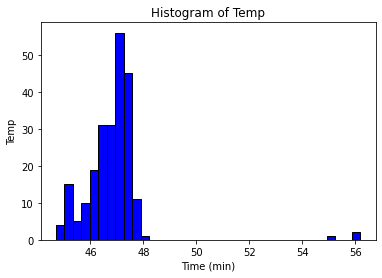

In [ ]:
plt.hist(df['temp'], color = 'blue', edgecolor = 'black',
         bins = int(180/5))
plt.title('Histogram of Temp')
plt.xlabel('Time (min)')
plt.ylabel('Temp')

Z score

In [ ]:
outliers = []
def detect_outliers(data):
  threshold = 3
  mean = np.mean(data)
  std = np.std(data)

  for i in data:
    z_score = (i-mean)/std
    if np.abs(z_score) > threshold:
      outliers.append(i)
  return outliers

In [ ]:
outlier_pt = detect_outliers(mylist)
outliers

[55.1, 56.1, 56.2]

In [ ]:
df_drop=df.loc[df['temp'] != 55.1]
df_drop2=df_drop.loc[df['temp'] != 56.1]
df_new=df_drop2.loc[df['temp'] != 56.2]

In [ ]:
df_new.shape

(228, 3)

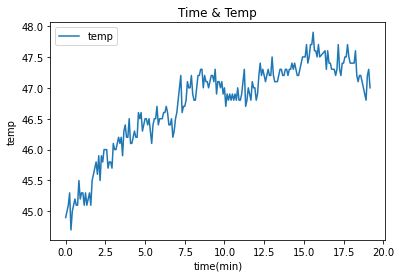

In [ ]:
df_new.plot(x='time_min', y='temp')
plt.title('Time & Temp')
plt.xlabel('time(min)')
plt.ylabel('temp')
plt.show()

In [ ]:
df_new.describe()

,time_sec,time_min,temp
count,228.000000,228.000000,228.000000
mean,569.802632,9.496711,46.727193
std,333.220939,5.553682,0.708325
min,0.000000,0.000000,44.700000
25%,283.750000,4.729167,46.300000
50%,567.500000,9.458333,46.900000
75%,851.250000,14.187500,47.225000
max,1150.000000,19.166667,47.900000


Inter-quantile range

In [ ]:
quantile1, quantile3 = np.percentile(mylist,[25,75])
print(quantile1, quantile3)

46.349999999999994 47.3


In [ ]:
iqr_value = quantile3 - quantile1
print(iqr_value)

0.9500000000000028


In [ ]:
lower_bound_val = quantile1 - (1.5 * iqr_value)
upper_bound_val = quantile3 + (1.5 * iqr_value)
print(lower_bound_val,upper_bound_val)

44.92499999999999 48.725


In [ ]:
df_drop = df.loc[df['temp'] >= lower_bound_val]
df_drop2 = df_drop.loc[df_drop['temp'] <= upper_bound_val]

In [ ]:
df_drop2.shape

(226, 3)

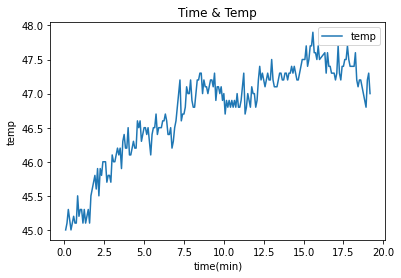

In [ ]:
df_drop2.plot(x='time_min', y='temp')
plt.title('Time & Temp')
plt.xlabel('time(min)')
plt.ylabel('temp')
plt.show()

Train & Test Split

In [ ]:
y = df_new.temp
x = df_new.drop(['temp','time_sec'],axis=1)

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [ ]:
x_train.shape

(182, 1)

In [ ]:
x_test.shape

(46, 1)

LinearRegression

coefficient:  [0.11531142]
intercept:  45.63929612376126
--------------------------------------------------
Predict on Train set
MAE =  0.2611782479934171
MSE =  0.1174090823833714
RMSE =  0.3426500873826992
R2 =  0.7761914535731257
--------------------------------------------------
Predict on Test set
MAE =  0.239922345899309
MSE =  0.09604971077014081
RMSE =  0.3099188777247053
R2 =  0.7538022240652946


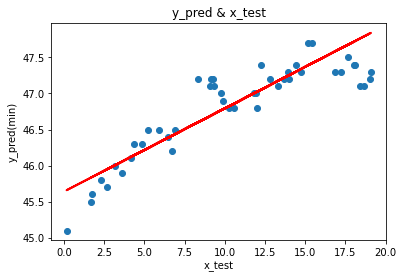

In [ ]:
#training
lr = LinearRegression()
lr.fit(x_train,y_train)

print ("coefficient: ", lr.coef_)
print ("intercept: ", lr.intercept_)

y_train_pred = lr.predict(x_train)
print(50 * '-')
print('Predict on Train set')
print('MAE = ',metrics.mean_absolute_error(y_train,y_train_pred))
print('MSE = ',metrics.mean_squared_error(y_train,y_train_pred)) 
print('RMSE = ',np.sqrt(metrics.mean_squared_error(y_train,y_train_pred)))
print('R2 = ',r2_score(y_train,y_train_pred))

y_pred = lr.predict(x_test)
print(50 * '-')
print('Predict on Test set')
print('MAE = ',metrics.mean_absolute_error(y_test,y_pred))
print('MSE = ',metrics.mean_squared_error(y_test,y_pred)) 
print('RMSE = ',np.sqrt(metrics.mean_squared_error(y_test,y_pred)))
print('R2 = ',r2_score(y_test,y_pred))

#จุดplot ค่าจริง
plt.scatter(x_test,y_test)
#เส้นตรงจากการpridict
plt.plot(x_test, y_pred, color='red', linewidth=2)
plt.title('y_pred & x_test')
plt.xlabel('x_test')
plt.ylabel('y_pred(min)')
plt.show()

In [ ]:
print ("mean accuracy: ", lr.score(x_train, y_train))

mean accuracy:  0.7734501387175128


In [ ]:
# compare true data & predict data ความคลาดเคลื่อน
df2 = pd.DataFrame({'Actually':y_test, 'Predicted':y_pred}) 
df2.head()

,Actually,Predicted
139,46.9,46.959349
203,47.3,47.551463
122,46.9,46.802069
185,47.7,47.384931
141,47.1,46.977853


In [ ]:
df3 = df2.head(20)
df2.plot(kind='bar', figsize=(16,8))
plt.show()

ทดลอง Predict

In [ ]:
x_max = (80-45.68335397077816)/0.10868957
x_max_hr = x_max/60
x_max_hr

5.262180175034557

In [ ]:
y_max = [[80]]
y_pred_test= lr.predict(np.array(y_max))
print ("y_pred on x_max: ", y_pred_test)
print ("y_pred on x_max: ", y_pred_test/60)
print ("y_pred on x_max: ", y_pred_test%60)

y_pred on x_max:  [54.55505599]
y_pred on x_max:  [0.90925093]
y_pred on x_max:  [54.55505599]


Polynomial

In [ ]:
 from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
poly.fit(x_train,y_train)



AttributeError: ignored

K-fold

In [ ]:
lr = LinearRegression()

# use 3-fold CV with default value of cv

# use 3-fold CV with defined cross validator "cv3"
cv3 = KFold(n_splits = 3, shuffle=True, random_state = 1)
cv_results = cross_validate(lr, x_train, y_train, cv=cv3, return_train_score=True)


# print out return value from cv
print (cv_results.keys())
cv_results['train_score']

dict_keys(['fit_time', 'score_time', 'test_score', 'train_score'])


array([0.76182578, 0.7926388 , 0.75879957])

**Lasso**
Lasso regression
โมเดลเหมือนกับ regression ทุกอย่างเลย ต่างกันที่ loss function เท่านั้น (loss function ของ lasso คือการเอา MSE บวกกับ Regularization term ตามรูปด้านล่างเลย) ปกติ lasso เวลาที่มัน learn ในแต่ละ batch มันก็จะไปรับ weight แต่การปรับ weight ของ lasso นี้มันจะมีกลไกในการ switch on-off ของ weight สำหรับแต่ละตัวแปร ดังนั้น ในแต่ละ epoch มันจึงดูเหมือน lasso เลือกบาง feature มาเรียนรู้ ซึ่งจริงๆแล้วมันคือ regularization technique
(เเล้วดีกว่า regression ปกติยังไงอ่า?? เมื่อไหร่ก็ตามที่ ตัวเเปร x มีมากกว่า 1 ตัวเเปร จะถูกเรียกว่า multiple linear regression ไอ้ตัวเเปร x หลายๆตัวนี่เเหละที่มักจะละเมิด assumption ของ regression นั่นคือ ต้องไม่เกิดปัญหา multicollinearity ซึ่ง lasso เลยเข้ามาช่วยเเก้ปัญหานี้เด้อ )

ต่อมาเราจะพูดถึงปัญหา **Over fitting**
คือการที่ Model เราทำนายได้แม่นยำมากับ training set แต่แย่กับ test set

In [ ]:
#1.การคัดเลือกตัวแปรใน multiple regression
#2.ฟังก์ชั่นการถดถอยจะตอบสนองต่อตัวทำนายมากเกินไปซึ่งจะถือว่าตัวทำนายนั้นสำคัญกว่า (วัดจากขนาดของสัมประสิทธิ์) 
#มากกว่าที่เป็นจริง กล่าวอีกนัยหนึ่งคือ overfitting แต่โดยทั่วไปแล้ว OLS จะให้การประมาณที่ไม่เอนเอียงและสอดคล้องกัน

#กำหนดค่า alpha และเลือกbest estimatorในการfit modle โดยใช้ gridsearchCV เพื่อเลือกโมเดลที่เหมาะสม


from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
params ={'alpha' :[0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000]}
las_so =GridSearchCV(Lasso(), params ,cv =15,
                     scoring = 'neg_mean_absolute_error', n_jobs =-1)
las_so.fit(x_train ,y_train)
las_so.best_estimator_.fit(x_train ,y_train)
print("Best Estimator: ",las_so.best_estimator_.fit(x_train ,y_train))
print(50 * '-')
print ("coefficient: ", las_so.best_estimator_.coef_)
print ("intercept: ", las_so.best_estimator_.intercept_)
y_train_pred = las_so.predict(x_train)
print(50 * '-')
print('Predict on Train set')
print('MAE = ',metrics.mean_absolute_error(y_train,y_train_pred))
print('MSE = ',metrics.mean_squared_error(y_train,y_train_pred)) 
print('RMSE = ',np.sqrt(metrics.mean_squared_error(y_train,y_train_pred)))
print('R2 = ',r2_score(y_train,y_train_pred))
y_pred = las_so.predict(x_test)
print(50 * '-')
print('Predict on Test set')
print('MAE = ',metrics.mean_absolute_error(y_test,y_pred))
print('MSE = ',metrics.mean_squared_error(y_test,y_pred)) 
print('RMSE = ',np.sqrt(metrics.mean_squared_error(y_test,y_pred)))
print('R2 = ',r2_score(y_test,y_pred))



Best Estimator:  Lasso(alpha=0.1, copy_X=True, fit_intercept=True, max_iter=1000,
      normalize=False, positive=False, precompute=False, random_state=None,
      selection='cyclic', tol=0.0001, warm_start=False)
--------------------------------------------------
coefficient:  [0.11204591]
intercept:  45.66945871215197
--------------------------------------------------
Predict on Train set
MAE =  0.26114102024377583
MSE =  0.11773563318417123
RMSE =  0.3431262642004707
R2 =  0.7755689731092814
--------------------------------------------------
Predict on Test set
MAE =  0.2369230978791199
MSE =  0.09325809497050119
RMSE =  0.30538188382826703
R2 =  0.7609577854472569


In [ ]:
x_max = (80-45.70355031011869)/0.10777485
x_max_hr = x_max/60
x_max_hr

5.30371876955853

In [ ]:
x_max = [[80]]
y_pred_test= las_so.predict(np.array(x_max))
print ("y_pred on x_max: ", y_pred_test)
print ("y_pred on x_max: ", y_pred_test%60)

y_pred on x_max:  [240.5926678]
y_pred on x_max:  [0.5926678]


**Rigde**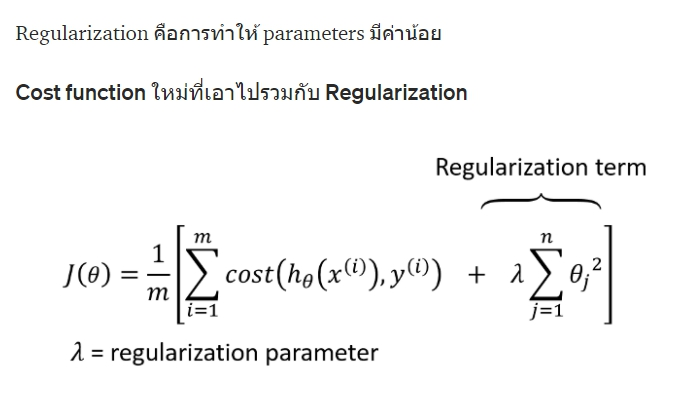

In [ ]:
#กำหนดค่า alpha และเลือกbest estimatorในการfit modle โดยใช้ gridsearchCV เพื่อเลือกโมเดลที่เหมาะสม
#alpha คือค่าที่ทำให้ loss function ต่ำสุด


from sklearn.linear_model import Ridge

params ={'alpha' :[ 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000]}
ridge_regressor =GridSearchCV(Ridge(), params ,cv =15,
                              scoring = 'neg_mean_absolute_error', n_jobs =-1)
ridge_regressor.fit(x_train ,y_train)
ridge_regressor.best_estimator_.fit(x_train ,y_train)
print("Best Estimator: ",ridge_regressor.best_estimator_.fit(x_train ,y_train))

print(50 * '-')
print ("coefficient: ", ridge_regressor.best_estimator_.coef_)
print ("intercept: ", ridge_regressor.best_estimator_.intercept_)
y_train_pred = ridge_regressor.predict(x_train)
print(50 * '-')
print('Predict on Train set')
print('MAE = ',metrics.mean_absolute_error(y_train,y_train_pred))
print('MSE = ',metrics.mean_squared_error(y_train,y_train_pred)) 
print('RMSE = ',np.sqrt(metrics.mean_squared_error(y_train,y_train_pred)))
print('R2 = ',r2_score(y_train,y_train_pred))
y_pred = ridge_regressor.predict(x_test)
print(50 * '-')
print('Predict on Test set')
print('MAE = ',metrics.mean_absolute_error(y_test,y_pred))
print('MSE = ',metrics.mean_squared_error(y_test,y_pred)) 
print('RMSE = ',np.sqrt(metrics.mean_squared_error(y_test,y_pred)))
print('R2 = ',r2_score(y_test,y_pred))


Best Estimator:  Ridge(alpha=100, copy_X=True, fit_intercept=True, max_iter=None,
      normalize=False, random_state=None, solver='auto', tol=0.001)
--------------------------------------------------
coefficient:  [0.11327893]
intercept:  45.65806967163167
--------------------------------------------------
Predict on Train set
MAE =  0.26106201130831647
MSE =  0.11753558696267423
RMSE =  0.3428346350103417
R2 =  0.7759503069306738
--------------------------------------------------
Predict on Test set
MAE =  0.237992955202571
MSE =  0.09423353649399324
RMSE =  0.3069748141036871
R2 =  0.7584575016701114


In [ ]:
x_max = [[80]]
y_pred_test= ridge_regressor.predict(np.array(x_max))
print ("y_pred on x_max: ", y_pred_test)
print ("y_pred on x_max: ", y_pred_test%60)

y_pred on x_max:  [240.59917089]
y_pred on x_max:  [0.59917089]


**Elastic net** 

In [ ]:
from sklearn.linear_model import ElasticNet

params ={'alpha' :[ 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000]}
elastic_regressor =GridSearchCV(ElasticNet(), params ,cv =15,
                              scoring = 'neg_mean_absolute_error', n_jobs =-1)
elastic_regressor.fit(x_train ,y_train)
elastic_regressor.best_estimator_.fit(x_train ,y_train)
print("Best Estimator: ",elastic_regressor.best_estimator_.fit(x_train ,y_train))

print(50 * '-')
print ("coefficient: ", elastic_regressor.best_estimator_.coef_)
print ("intercept: ", elastic_regressor.best_estimator_.intercept_)
y_train_pred = elastic_regressor.predict(x_train)
print(50 * '-')
print('Predict on Train set')
print('MAE = ',metrics.mean_absolute_error(y_train,y_train_pred))
print('MSE = ',metrics.mean_squared_error(y_train,y_train_pred)) 
print('RMSE = ',np.sqrt(metrics.mean_squared_error(y_train,y_train_pred)))
print('R2 = ',r2_score(y_train,y_train_pred))
y_pred = elastic_regressor.predict(x_test)
print(50 * '-')
print('Predict on Test set')
print('MAE = ',metrics.mean_absolute_error(y_test,y_pred))
print('MSE = ',metrics.mean_squared_error(y_test,y_pred)) 
print('RMSE = ',np.sqrt(metrics.mean_squared_error(y_test,y_pred)))
print('R2 = ',r2_score(y_test,y_pred))

Best Estimator:  ElasticNet(alpha=0.1, copy_X=True, fit_intercept=True, l1_ratio=0.5,
           max_iter=1000, normalize=False, positive=False, precompute=False,
           random_state=None, selection='cyclic', tol=0.0001, warm_start=False)
--------------------------------------------------
coefficient:  [0.1125808]
intercept:  45.64629463155295
--------------------------------------------------
Predict on Train set
MAE =  0.2677475871840443
MSE =  0.11935895430275735
RMSE =  0.345483652728689
R2 =  0.775701675675265
--------------------------------------------------
Predict on Test set
MAE =  0.22783094285953648
MSE =  0.08733502902436506
RMSE =  0.2955250057514001
R2 =  0.7632244853674532


**KNN**
จำนวน k ที่น้อยไปเป็นผลให้ความแม่นยำลดลง เช่น การเชื่อข้อมูลเพียงหนึ่งตัว (k = 1) เป็นต้น จำนวน k ที่มากไปก็ไม่ใช่เรื่องดีเช่นกัน เพราะยิ่งขยายค่า k มากเท่าใด ยิ่งมีโอกาสครอบคลุมพื้นที่ของข้อมูลที่ไม่เกี่ยวข้อง (คนละประเภท) มากขึ้นด้วยเท่านั้น

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
#กำหนดค่าkในlistแล้วใส่ในparamsเพื่อให้gridsearchหาโมเดลที่ดีที่สุด 
k_range = list(range(1, 30))
params = dict(n_neighbors = k_range)
knn_regressor = GridSearchCV(KNeighborsRegressor(), 
                             params, cv =10, scoring = 'neg_mean_squared_error')
knn_regressor.fit(x_train, y_train)
knn_regressor.best_estimator_.fit(x_train ,y_train)

print("Best Estimator: ",knn_regressor.best_estimator_.fit(x_train ,y_train))

y_train_pred = knn_regressor.predict(x_train)
print(50 * '-')
print('Predict on Train set')
print('MAE = ',metrics.mean_absolute_error(y_train,y_train_pred))
print('MSE = ',metrics.mean_squared_error(y_train,y_train_pred)) 
print('RMSE = ',np.sqrt(metrics.mean_squared_error(y_train,y_train_pred)))
print('R2 = ',r2_score(y_train,y_train_pred))

y_pred = knn_regressor.predict(x_test)
print(50 * '-')
print('Predict on Test set')
print('MAE = ',metrics.mean_absolute_error(y_test,y_pred))
print('MSE = ',metrics.mean_squared_error(y_test,y_pred)) 
print('RMSE = ',np.sqrt(metrics.mean_squared_error(y_test,y_pred)))
print('R2 = ',r2_score(y_test,y_pred))

Best Estimator:  KNeighborsRegressor(algorithm='auto', leaf_size=30, metric='minkowski',
                    metric_params=None, n_jobs=None, n_neighbors=22, p=2,
                    weights='uniform')
--------------------------------------------------
Predict on Train set
MAE =  1.5418539793539792
MSE =  5.438540389534706
RMSE =  2.33206783553453
R2 =  0.8234411705136031
--------------------------------------------------
Predict on Test set
MAE =  1.623435441370224
MSE =  5.092093426857507
RMSE =  2.2565667344125915
R2 =  0.8278955803439657


In [ ]:
x_max = [[80]]
y_pred_test= knn_regressor.predict(np.array(x_max))
print ("y_pred on x_max: ", y_pred_test)

y_pred on x_max:  [16.24621212]


RandomForrest

In [ ]:
from sklearn import ensemble
from sklearn.datasets import make_regression
regr = ensemble.RandomForestRegressor(n_estimators=100, 
                                      max_depth=5, random_state=0)
regr.fit(x_train, y_train)  

y_train_pred = regr.predict(x_train)
print(50 * '-')
print('Predict on Train set')
print('MAE = ',metrics.mean_absolute_error(y_train,y_train_pred))
print('MSE = ',metrics.mean_squared_error(y_train,y_train_pred)) 
print('RMSE = ',np.sqrt(metrics.mean_squared_error(y_train,y_train_pred)))
print('R2 = ',r2_score(y_train,y_train_pred))

y_pred = regr.predict(x_test)
print(50 * '-')
print('Predict on Test set')
print('MAE = ',metrics.mean_absolute_error(y_test,y_pred))
print('MSE = ',metrics.mean_squared_error(y_test,y_pred)) 
print('RMSE = ',np.sqrt(metrics.mean_squared_error(y_test,y_pred)))
print('R2 = ',r2_score(y_test,y_pred))




--------------------------------------------------
Predict on Train set
MAE =  1.4464308485478703
MSE =  5.080349421251809
RMSE =  2.2539630478896076
R2 =  0.8350696174061412
--------------------------------------------------
Predict on Test set
MAE =  1.6230278787918617
MSE =  5.4267921380806134
RMSE =  2.3295476252012133
R2 =  0.8165833119651382


In [ ]:
x_max = [[80]]
y_pred_test= regr.predict(np.array(x_max))
print ("y_pred on x_max: ", y_pred_test)

y_pred on x_max:  [15.2132648]


Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor
# กำหนดdepth เพื่อเป็นparamsให้gridsearchหาโมเดลที่ดีที่สุด
depth  =list(range(3,30)) #ความลึกของต้นไม้(กี่ขั้น)
param_grid =dict(max_depth =depth)
tree =GridSearchCV(DecisionTreeRegressor(),param_grid,cv =15)
tree.fit(x_train,y_train)
tree.best_estimator_.fit(x_train,y_train)

print("Best Estimator: ",tree.best_estimator_.fit(x_train ,y_train))

y_train_pred = tree.predict(x_train)
print(50 * '-')
print('Predict on Train set')
print('MAE = ',metrics.mean_absolute_error(y_train,y_train_pred))
print('MSE = ',metrics.mean_squared_error(y_train,y_train_pred)) 
print('RMSE = ',np.sqrt(metrics.mean_squared_error(y_train,y_train_pred)))
print('R2 = ',r2_score(y_train,y_train_pred))

y_pred = tree.predict(x_test)
print(50 * '-')
print('Predict on Test set')
print('MAE = ',metrics.mean_absolute_error(y_test,y_pred))
print('MSE = ',metrics.mean_squared_error(y_test,y_pred)) 
print('RMSE = ',np.sqrt(metrics.mean_squared_error(y_test,y_pred)))
print('R2 = ',r2_score(y_test,y_pred))

Best Estimator:  DecisionTreeRegressor(ccp_alpha=0.0, criterion='mse', max_depth=5,
                      max_features=None, max_leaf_nodes=None,
                      min_impurity_decrease=0.0, min_impurity_split=None,
                      min_samples_leaf=1, min_samples_split=2,
                      min_weight_fraction_leaf=0.0, presort='deprecated',
                      random_state=None, splitter='best')
--------------------------------------------------
Predict on Train set
MAE =  1.4502489573918147
MSE =  5.073374021811522
RMSE =  2.2524151530771412
R2 =  0.8352960694083635
--------------------------------------------------
Predict on Test set
MAE =  1.620839215132693
MSE =  5.4877274390599755
RMSE =  2.3425898998885777
R2 =  0.8145237985720206


In [ ]:
x_max = [[80]]
y_pred_test= tree.predict(np.array(x_max))
print ("y_pred on x_max: ", y_pred_test)

y_pred on x_max:  [16.31481481]


SVR

In [ ]:
from sklearn.svm import SVR

params = {'C' : [1,5,10,15,20]}
#ใช้gridsearchเพื่อหาโมเดลที่ดีที่สุดจากparams
svr_reg = GridSearchCV(SVR(), params, cv =10, scoring = 'neg_mean_squared_error')
svr_reg.fit(x_train,y_train)


svr_reg.best_estimator_.fit(x_train ,y_train)

SVR(C=15, cache_size=200, coef0=0.0, degree=3, epsilon=0.1, gamma='scale',
    kernel='rbf', max_iter=-1, shrinking=True, tol=0.001, verbose=False)

In [ ]:
x_max = [[80]]
y_pred_test= svr_reg.predict(np.array(x_max))
print ("y_pred on x_max: ", y_pred_test)

y_pred on x_max:  [6.96871602]


XGB Regressor

In [ ]:
from xgboost import XGBRegressor

#กำหนดparamsเพื่อให้gridsearchหาโมเดลที่ดีที่สุด
tuned_params = {'max_depth': [1, 2, 3, 4, 5], 'learning_rate': [0.01, 0.05, 0.1], 'n_estimators': [100, 200, 300, 400, 500], 'reg_lambda': [0.001, 0.1, 1.0, 10.0, 100.0]}
xgb_regr = RandomizedSearchCV(XGBRegressor(), tuned_params, n_iter=20, scoring = 'neg_mean_absolute_error', cv=5, n_jobs=-1)
xgb_regr.fit(x_train, y_train)

[02:39:19] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


RandomizedSearchCV(cv=5, error_score=nan,
                   estimator=XGBRegressor(base_score=0.5, booster='gbtree',
                                          colsample_bylevel=1,
                                          colsample_bynode=1,
                                          colsample_bytree=1, gamma=0,
                                          importance_type='gain',
                                          learning_rate=0.1, max_delta_step=0,
                                          max_depth=3, min_child_weight=1,
                                          missing=None, n_estimators=100,
                                          n_jobs=1, nthread=None,
                                          objective='reg:linear',
                                          random_state=0, reg_alpha=...
                                          seed=None, silent=None, subsample=1,
                                          verbosity=1),
                   iid='deprecated', n_iter=20, n_job

In [ ]:
x_max = [[80]]
y_pred_test= xgb_regr.predict(np.array(x_max))
print ("y_pred on x_max: ", y_pred_test)

ValueError: ignored

**รื้อโค้ดใหม่**

In [ ]:
import pandas as pd
import numpy as np
from sklearn import metrics
from sklearn import linear_model
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV, train_test_split

In [ ]:
def test(models, data, iterations = 100):
    results = {}
    for i in models:
        r2_train = []
        r2_test = []
        for j in range(iterations):
            x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2)
            r2_test.append(metrics.r2_score(y_test,models[i].fit(x_train, y_train).predict(x_test)))
            r2_train.append(metrics.r2_score(y_train, models[i].fit(x_train, y_train).predict(x_train)))
        results[i] = [np.mean(r2_train), np.mean(r2_test)]
    return pd.DataFrame(results)

model 1 แบ่ง test = 0.2

In [ ]:
models = {'OLS': linear_model.LinearRegression(),
         'Lasso': linear_model.Lasso(),
         'Ridge': linear_model.Ridge(),}

In [ ]:
test(models, df_new)

,OLS,Lasso,Ridge
0,0.775419,0.709057,0.773928
1,0.751527,0.699395,0.762957


In [ ]:
lasso_params = {'alpha':[0.02, 0.024, 0.025, 0.026, 0.03]}
ridge_params = {'alpha':[0.02, 0.024, 0.025, 0.026, 0.03]}

models2 = {'OLS': linear_model.LinearRegression(),
           'Lasso': GridSearchCV(linear_model.Lasso(),cv=5, param_grid=lasso_params).fit(x, y).best_estimator_,
           'Ridge': GridSearchCV(linear_model.Ridge(), cv=5,param_grid=ridge_params).fit(x, y).best_estimator_,}


In [ ]:
test(models2, df_new) #Note Lasso win

,OLS,Lasso,Ridge
0,0.775979,0.775468,0.775486
1,0.749832,0.755977,0.750379


In [ ]:
lasso_params = {'fit__alpha':[0.005, 0.02, 0.03, 0.05, 0.06]}
ridge_params = {'fit__alpha':[0.005, 0.02, 0.03, 0.05, 0.06]}

pipe1 = Pipeline([('poly', PolynomialFeatures()),
                 ('fit', linear_model.LinearRegression())])
pipe2 = Pipeline([('poly', PolynomialFeatures()),
                 ('fit', linear_model.Lasso())])
pipe3 = Pipeline([('poly', PolynomialFeatures()),
                 ('fit', linear_model.Ridge())])

models3 = {'OLS': pipe1,
           'Lasso': GridSearchCV(pipe2, 
                                 param_grid=lasso_params).fit(x, y).best_estimator_ ,
           'Ridge': GridSearchCV(pipe3, 
                                 param_grid=ridge_params).fit(x, y).best_estimator_,}

In [ ]:
test(models3, df_new)

,OLS,Lasso,Ridge
0,0.915003,0.913561,0.914428
1,0.905977,0.906170,0.910079
